In [11]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f)

ROOT = Path("..")

wsd_raw    = read_jsonl(ROOT / "logs/wsd_intermediate_paper_decay_20260605-154459/metrics.jsonl")
cosine_raw = read_jsonl(ROOT / "logs/cosine_intermediate_paper_decay_20260605-154448/metrics.jsonl")

wsd_train    = wsd_raw[wsd_raw["train_loss"].notna()].reset_index(drop=True)
wsd_val      = wsd_raw[wsd_raw["validation_loss"].notna()].reset_index(drop=True) if "validation_loss" in wsd_raw.columns else None

cosine_train = cosine_raw[cosine_raw["train_loss"].notna()].reset_index(drop=True)
cosine_val   = cosine_raw[cosine_raw["validation_loss"].notna()].reset_index(drop=True) if "validation_loss" in cosine_raw.columns else None

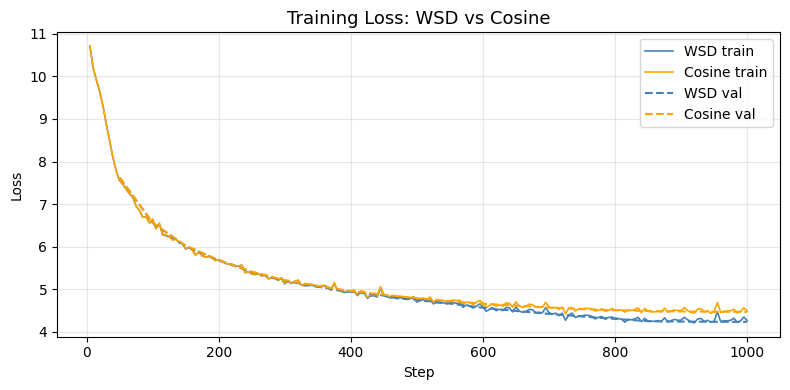

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(wsd_train["step"],    wsd_train["train_loss"],    color="steelblue", linewidth=1.2, label="WSD train")
ax.plot(cosine_train["step"], cosine_train["train_loss"], color="orange",    linewidth=1.2, label="Cosine train")

if wsd_val is not None and len(wsd_val) > 0:
    ax.plot(wsd_val["step"], wsd_val["validation_loss"], color="steelblue", linewidth=1.5, linestyle="--", label="WSD val")
if cosine_val is not None and len(cosine_val) > 0:
    ax.plot(cosine_val["step"], cosine_val["validation_loss"], color="orange", linewidth=1.5, linestyle="--", label="Cosine val")

ax.set_title("Training Loss: WSD vs Cosine", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

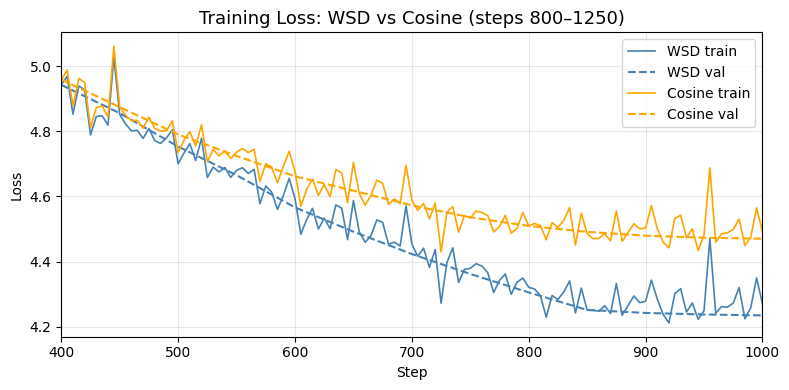

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

for train_df, val_df, color, name in [
    (wsd_train,    wsd_val,    "steelblue", "WSD"),
    (cosine_train, cosine_val, "orange",    "Cosine"),
]:
    mask = train_df["step"].between(400, 1000)
    ax.plot(train_df.loc[mask, "step"], train_df.loc[mask, "train_loss"], color=color, linewidth=1.2, label=f"{name} train")
    if val_df is not None and len(val_df) > 0:
        val_mask = val_df["step"].between(400, 1000)
        ax.plot(val_df.loc[val_mask, "step"], val_df.loc[val_mask, "validation_loss"], color=color, linewidth=1.5, linestyle="--", label=f"{name} val")

ax.set_xlim(400, 1000)
ax.set_title("Training Loss: WSD vs Cosine (steps 800\u20131250)", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

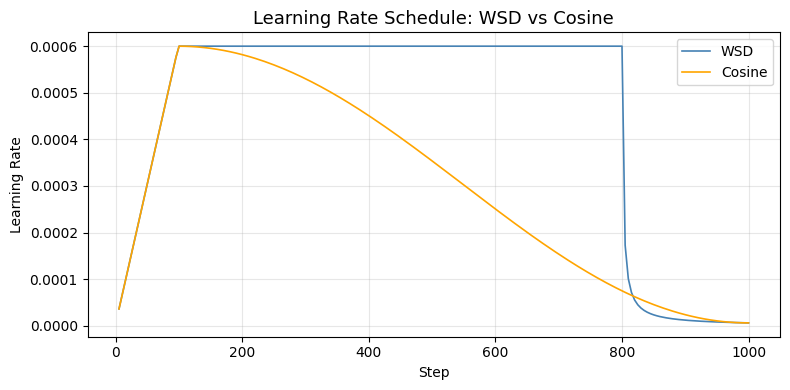

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(wsd_train["step"],    wsd_train["learning_rate"],    color="steelblue", linewidth=1.2, label="WSD")
ax.plot(cosine_train["step"], cosine_train["learning_rate"], color="orange",    linewidth=1.2, label="Cosine")

ax.set_title("Learning Rate Schedule: WSD vs Cosine", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()